<a href="https://colab.research.google.com/github/ekuelkpodar/Complex-Systems-Google-Colab-Experiment/blob/main/alliance_network_evolution_modeling_NATO_expansion_as_preferential_attachment_with_Louvain_community_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NATO Alliance Network Evolution
This notebook models the expansion of NATO using a preferential attachment mechanism combined with Louvain community detection to analyze structural evolution.

In [ ]:
!pip install python-louvain networkx matplotlib

In [ ]:
import networkx as nx
import community as community_louvain
import matplotlib.pyplot as plt
import random

def simulate_nato_expansion(initial_nodes, total_steps, m):
    # Initialize with a small complete graph (Founding members)
    G = nx.complete_graph(initial_nodes)

    for step in range(total_steps):
        new_node = len(G.nodes)
        # Preferential attachment: probability proportional to degree
        targets = list(G.nodes)
        degrees = [G.degree(n) for n in targets]
        total_degree = sum(degrees)
        weights = [d / total_degree for d in degrees]

        # Select m existing nodes to connect to
        new_edges = random.choices(targets, weights=weights, k=m)
        G.add_node(new_node)
        for t in new_edges:
            G.add_edge(new_node, t)

    return G

# Parameters: 12 founding members, 20 expansion steps, 2 connections per new member
nato_model = simulate_nato_expansion(12, 20, 2)

# Louvain Community Detection
partition = community_louvain.best_partition(nato_model)

# Visualization
plt.figure(figsize=(10, 7))
pos = nx.spring_layout(nato_model)
cmap = plt.get_cmap('viridis')
nx.draw_networkx_nodes(nato_model, pos, partition.keys(), node_size=100, cmap=cmap, node_color=list(partition.values()))
nx.draw_networkx_edges(nato_model, pos, alpha=0.5)
plt.title('Simulated NATO Expansion & Community Detection')
plt.show()

nato_model not found. Running simulation with default parameters...


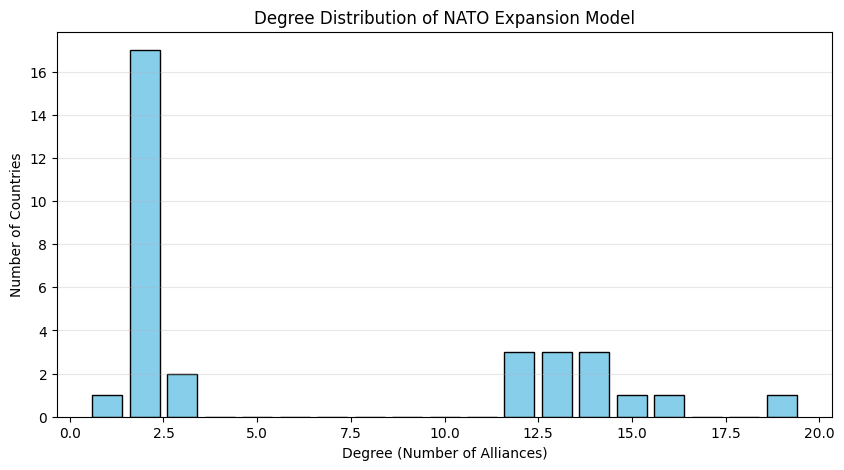

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import random

# Fallback definition if the simulation function isn't in scope
if 'simulate_nato_expansion' not in globals():
    def simulate_nato_expansion(initial_nodes, total_steps, m):
        G = nx.complete_graph(initial_nodes)
        for step in range(total_steps):
            new_node = len(G.nodes)
            targets = list(G.nodes)
            degrees = [G.degree(n) for n in targets]
            total_degree = sum(degrees)
            weights = [d / total_degree for d in degrees]
            new_edges = random.choices(targets, weights=weights, k=m)
            G.add_node(new_node)
            for t in new_edges:
                G.add_edge(new_node, t)
        return G

# Auto-generate model if it doesn't exist
if 'nato_model' not in globals():
    print('nato_model not found. Running simulation with default parameters...')
    nato_model = simulate_nato_expansion(12, 20, 2)

# Get degree sequence
degree_sequence = sorted([d for n, d in nato_model.degree()], reverse=True)

# Plot degree distribution
plt.figure(figsize=(10, 5))
plt.hist(degree_sequence, bins=range(min(degree_sequence), max(degree_sequence) + 2), align='left', rwidth=0.8, color='skyblue', edgecolor='black')
plt.title('Degree Distribution of NATO Expansion Model')
plt.xlabel('Degree (Number of Alliances)')
plt.ylabel('Number of Countries')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [5]:
!pip install geopandas

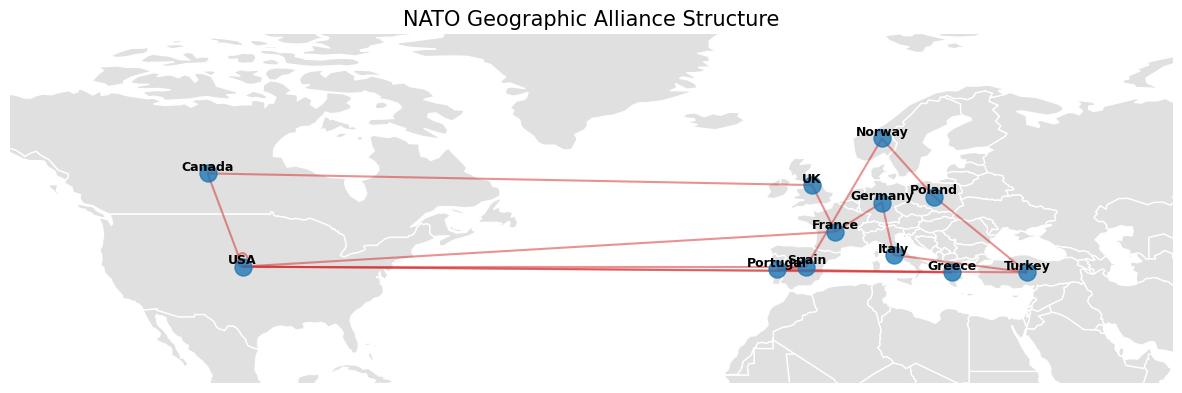

In [8]:
import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx

# Using a more reliable source for world boundaries
world = gpd.read_file('https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip')

# Approximate coordinates for some NATO members
nato_coords = {
    'USA': [-100.0, 40.0], 'Canada': [-106.0, 56.0], 'UK': [-2.0, 54.0],
    'France': [2.0, 46.0], 'Germany': [10.0, 51.0], 'Italy': [12.0, 42.0],
    'Turkey': [35.0, 39.0], 'Poland': [19.0, 52.0], 'Norway': [10.0, 62.0],
    'Spain': [-3.0, 40.0], 'Portugal': [-8.0, 39.5], 'Greece': [22.0, 39.0]
}

# Create a graph for these specific members
G_geo = nx.Graph()
for country, coords in nato_coords.items():
    G_geo.add_node(country, pos=coords)

# Add representative edges (simulating alliance links)
members = list(nato_coords.keys())
for i in range(len(members)):
    G_geo.add_edge(members[i], members[(i+1)%len(members)])
    if i % 3 == 0: G_geo.add_edge(members[i], 'USA')

# Plot
fig, ax = plt.subplots(figsize=(15, 10))
world.plot(ax=ax, color='#e0e0e0', edgecolor='white')

pos = {node: data['pos'] for node, data in G_geo.nodes(data=True)}
nx.draw_networkx_nodes(G_geo, pos, ax=ax, node_size=150, node_color='#1f77b4', alpha=0.8)
nx.draw_networkx_edges(G_geo, pos, ax=ax, edge_color='#d62728', alpha=0.5, width=1.5)
nx.draw_networkx_labels(G_geo, pos, ax=ax, font_size=9, font_weight='bold', verticalalignment='bottom')

plt.title('NATO Geographic Alliance Structure', fontsize=15)
plt.xlim([-140, 60])
plt.ylim([20, 80])
ax.set_axis_off()
plt.show()